In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import istft
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from utils.LoRa import LoRa

import importlib
import utils.my_lora_utils
importlib.reload(utils.my_lora_utils)
from utils.my_lora_utils import *

print(utils.my_lora_utils.__file__)

c:\Users\priba\Sean-2025\INC-LAB\BAM\INC-BAM\utils\my_lora_utils.py


(64, 65)


FileNotFoundError: [Errno 2] No such file or directory: 'dataset_real_sf9/s_sf9_bw125_6_2_1.npy'

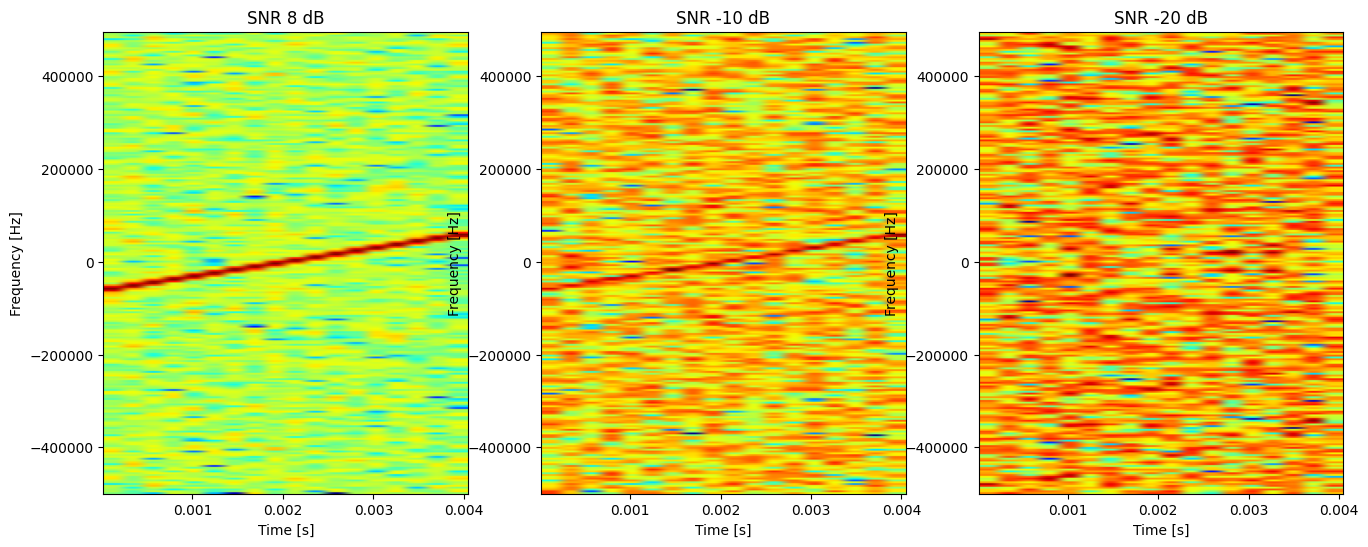

In [2]:
# ---- Example usage with your LoRa generator ----
sf = 9
bw = 125000
fs = 1000000
symbol_ = 0
lora_init = LoRa(sf, bw)
x = lora_init.gen_symbol_fs(symbol_, sf=sf, bw=bw, Fs=fs)  # you had Fs=int(bw*8)=1e6
snr = 8
x= lora_init.add_awgn_noise(x,snr)
x1 = lora_init.add_awgn_noise(x,-10)
x2 = lora_init.add_awgn_noise(x,-20)
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(16, 6))  # 2 columns per row
im1 = PLOT_SPECGRAM2(x, 256, "SNR 8 dB", ax=axs[0])
im2 = PLOT_SPECGRAM2(x1, 256, "SNR -10 dB", ax=axs[1])
im3 = PLOT_SPECGRAM2(x2, 256, "SNR -20 dB", ax=axs[2])
a,b,c,d,e,f = create_spectrogram_npy_dual(x,fs,0,0,0,None,None)
print(a.shape)

tess = np.load("dataset_real_sf9/s_sf9_bw125_6_2_1.npy")

tess2 = np.load("dataset_im_sf9/s_sf9_bw125_6_2_1.npy")

show_multiple_spectrograms([tess,tess2],["tes","real"],2)
a_inverse_norm =((a + 1) / 2) * (d - c) + c
b_inverse_norm =((b + 1) / 2) * (f - e) + e
Zxx_complex = a_inverse_norm + 1j * b_inverse_norm
print(c,d,e,f)
print(Zxx_complex.shape)

nperseg = 128 #128
noverlap = 64 # 64
nfft = 512 #512 : 2
# f_new, t_new, Zxx = stft(
#     x, fs=fs, window="hann", nperseg=nperseg,
#     noverlap=noverlap, nfft=nfft, padded=True, boundary="zeros",
#     return_onesided=False
# )
# Zxx_shift = np.fft.fftshift(Zxx, axes=0)
# Zxx_r = np.real(Zxx_shift)
# Zxx_i = np.imag(Zxx_shift)
# Zxx_r_norm = 2 * (Zxx_r - Zxx_r.min()) / (Zxx_r.max() - Zxx_r.min()) - 1
# Zxx_i_norm = 2 * (Zxx_i - Zxx_i.min()) / (Zxx_i.max() - Zxx_i.min()) - 1
# a_inverse_norm =((Zxx_r_norm + 1) / 2) * (Zxx_r.max() - Zxx_r.min()) + Zxx_r.min()
# b_inverse_norm =((Zxx_i_norm + 1) / 2) * (Zxx_i.max() - Zxx_i.min()) + Zxx_i.min()

Zxx_complex = a_inverse_norm + 1j * b_inverse_norm

Zxx_unshifted = np.fft.ifftshift(Zxx_complex, axes=0)
# PROCESS ISTF
_, x_rec = istft(
    Zxx_unshifted, fs=fs, window="hann", nperseg=nperseg,
    noverlap=noverlap, nfft=nfft, input_onesided=False
)
print(len(x_rec))
x2 = lora_init.gen_symbol_fs(symbol_, sf=sf, bw=bw, Fs=fs)  # you had Fs=int(bw*8)=1e6

PLOT_SPECGRAM(x_rec,128,"a",32,250000)
print(len(x2))
print(len(x_rec))
# x_rec = x2
sym,max = estimate_symbol_custom(x_rec,"a",9,250000,125000,tresshold = 0)
print(sym)
print(max)
# PLOT_SPECGRAM(x_ds,128,"a",32,fs/4)
# PLOT_SPECGRAM(x_rec,128,"a",32,fs/4)
# Compute FFT
sf = 9
bw = 125000
fs = 250000
symbol_time = 2**sf / bw  # Symbol duration
# Time vector
t = np.arange(0, symbol_time, 1/fs)
# Generate Downchirp (Linear Frequency Modulation)
f0 = -bw/2 # Start frequency
f1 = bw/2 # End frequency

# Generate Upchirp (increasing frequency)
up_chirp_signal = np.exp(1j * 2 * np.pi * (f0 * t + (f1 / ( symbol_time)) * t**2))
down_chirp_signal = np.conj(up_chirp_signal)
signal =x_rec * down_chirp_signal
PLOT_SPECGRAM(signal,128,"asdasd",32,250000)
X = np.fft.fft(signal)
N = len(X)
freq = np.fft.fftfreq(N, 1/250000)

# Magnitude
X_mag = np.abs(X)

# Plot FFT (normal)
plt.figure(figsize=(10,4))
plt.plot(freq[:N//2], X_mag[:N//2])
plt.title("FFT Magnitude Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.show()

# Optional: Plot centered FFT using fftshift
X_shift = np.fft.fftshift(X)
freq_shift = np.fft.fftshift(freq)
plt.figure(figsize=(10,4))
plt.plot(freq_shift, np.abs(X_shift))
plt.title("FFT Magnitude Spectrum (Centered)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.show()


In [ ]:
a = np.load("dataset_real_sf9_highsnr/s_sf9_bw125_30_0_1.npy")
print(a.shape)

show_multiple_spectrograms([a],"a",1)